In [1]:
import nucml.datasets as nuc_data
import numpy as np
import pandas as pd

# 1. Load just the experimental data for Gold-197 (n,2n)
print(">>> PROBING EXPERIMENTAL DATA (EXFOR)...")
df_all = nuc_data.load_exfor()
gold_exp = df_all[
    (df_all['Isotope'].str.lower().str.replace('-', '') == '197au') & 
    (df_all['MT'].astype(float) == 16.0)
].copy()

if gold_exp.empty:
    print("ERROR: Could not find 197Au (n,2n) in EXFOR. Checking naming...")
    # Fallback to check what IS there
    print(df_all[df_all['Z']==79]['Isotope'].unique())
else:
    exp_min = gold_exp['Energy'].min()
    exp_max = gold_exp['Energy'].max()
    print(f"Experimental Energy Range: {exp_min:.2f} to {exp_max:.2f}")
    
    # 2. Load the Evaluation (TENDL)
    print("\n>>> PROBING THEORETICAL DATA (TENDL)...")
    try:
        gold_eval = nuc_data.load_evaluation('197au', 16, library='tendl.2019')
        eval_min = gold_eval['Energy'].min()
        eval_max = gold_eval['Energy'].max()
        print(f"Theoretical Energy Range:  {eval_min:.2f} to {eval_max:.2f}")
        
        # 3. THE VERDICT
        print("\n>>> THE VERDICT:")
        if exp_max < 200 and eval_max > 1e5:
            print("MISMATCH DETECTED: Experiment is MeV, Theory is eV.")
            print("FIX: Multiply Experiment by 1,000,000.")
        elif exp_max > 1e5 and eval_max < 200:
            print("MISMATCH DETECTED: Experiment is eV, Theory is MeV.")
        else:
            print("Units appear aligned. The issue might be threshold definition.")
            
    except Exception as e:
        print(f"Could not load TENDL for comparison: {e}")

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv


>>> PROBING EXPERIMENTAL DATA (EXFOR)...


INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Au197/tendl.2019/tables/xs/n-Au197-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 65 datapoints.


Experimental Energy Range: 8125000.00 to 151600000.00

>>> PROBING THEORETICAL DATA (TENDL)...
Theoretical Energy Range:  6.91 to 8.30

>>> THE VERDICT:
MISMATCH DETECTED: Experiment is eV, Theory is MeV.


In [2]:
import nucml.datasets as nuc_data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Define Targets
target_isos = ['58ni', '28si', '93nb', '80kr', '197au', '164er']

# 2. Load Data
print("Loading EXFOR database...")
df_master_raw = nuc_data.load_exfor()

# 3. Filter for (n,2n) reaction (MT=16) and Mass 20-200
df_2n = df_master_raw[
    (df_master_raw['MT'].astype(float) == 16.0) & 
    (df_master_raw['A'] >= 20) & 
    (df_master_raw['A'] <= 200)
].copy()

# 4. Standardize Naming & Basic Physics
df_2n['Isotope_Norm'] = df_2n['Isotope'].str.lower().str.replace('-', '').str.strip()
df_2n['N'] = df_2n['A'] - df_2n['Z']
# We calculate Log Energy here for the Feature List, but we will recalculate it
# inside the auditor to ensure perfect alignment with TENDL.
df_2n['Energy_Log'] = np.log10(df_2n['Energy'] + 1e-5)

# 5. Adaptive Physics Features
features = ['A', 'Z', 'N', 'Energy_Log']
sn_cols = [c for c in df_2n.columns if c.lower() in ['sn', 's(n)', 'sep_energy']]

if sn_cols:
    print(f"Physics Feature Enabled: Separation Energy ('{sn_cols[0]}')")
    df_2n['E_minus_Sn'] = df_2n['Energy'] - df_2n[sn_cols[0]]
    features.extend([sn_cols[0], 'E_minus_Sn'])
else:
    print("Physics Note: Separation Energy not found. Using A, Z, N, E only.")

# 6. Create Master Pool
df_clean = df_2n[['Isotope', 'Isotope_Norm', 'Energy', 'Data'] + features].copy()

print(f"Master Dataframe Ready: {len(df_clean)} rows.")
print(f"Targets confirmed in pool: {df_clean[df_clean['Isotope_Norm'].isin(target_isos)]['Isotope_Norm'].unique()}")

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv


Loading EXFOR database...


INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)


Physics Feature Enabled: Separation Energy ('S(n)')
Master Dataframe Ready: 10403 rows.
Targets confirmed in pool: ['28si' '58ni' '80kr' '93nb' '164er' '197au']


In [3]:
import numpy as np
import pandas as pd

final_rows = []
unique_isos = df_clean['Isotope'].unique()

print(f"Auditing {len(unique_isos)} isotopes using Log-Space alignment...")

for i, iso in enumerate(unique_isos):
    iso_batch = df_clean[df_clean['Isotope'] == iso].copy()
    
    try:
        # 1. Load Theory (TENDL returns Energy in Log10 eV)
        tendl_df = nuc_data.load_evaluation(iso.lower(), 16, library='tendl.2019')
        if tendl_df is None or tendl_df.empty: continue
        
        # 2. Prepare Experimental Energy (Convert Linear eV -> Log10 eV)
        exp_energy_linear = iso_batch['Energy'].values.astype(float)
        exp_energy_log = np.log10(exp_energy_linear + 1e-5)
        
        # 3. Interpolate in LOG SPACE
        # We look up the Exp Log-Energy inside the Theory Log-Energy curve
        theory_xs = np.interp(
            exp_energy_log, 
            tendl_df['Energy'].values,  # Theory X (Log eV)
            tendl_df['Data'].values     # Theory Y (Cross Section)
        )
        
        # 4. Filter & Calculate Residuals
        # Keep data where theory is physically active (> 1e-9 barns)
        valid_mask = theory_xs > 1e-9
        
        if np.any(valid_mask):
            # Residual = Log(Exp_XS) - Log(Theory_XS)
            res = np.log10(iso_batch['Data'].values[valid_mask] + 1e-10) - np.log10(theory_xs[valid_mask] + 1e-10)
            
            # Store valid rows
            valid_batch = iso_batch.iloc[valid_mask].copy()
            valid_batch['residual'] = res
            valid_batch['theory_baseline'] = theory_xs[valid_mask]
            
            final_rows.append(valid_batch)
            
    except Exception as e:
        continue

# 5. Final Merge
if final_rows:
    df_final = pd.concat(final_rows, ignore_index=True)
    print(f"SUCCESS: Training pool populated with {len(df_final)} rows.")
else:
    print("CRITICAL FAILURE: No rows survived. Verify TENDL library path.")

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Na023/tendl.2019/tables/xs/n-Na023-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 50 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Mg024/tendl.2019/tables/xs/n-Mg024-MT016.tendl.20

Auditing 186 isotopes using Log-Space alignment...


INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 58 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Br079/tendl.2019/tables/xs/n-Br079-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarn

SUCCESS: Training pool populated with 5360 rows.


In [4]:
# 1. Split: Isolate Test Isotopes completely
test_set = df_final[df_final['Isotope_Norm'].isin(target_isos)].copy()
train_set = df_final[~df_final['Isotope_Norm'].isin(target_isos)].copy()

# 2. Scale Features (Fit on Train, Transform Test)
scaler = StandardScaler()
train_set[features] = scaler.fit_transform(train_set[features])
test_set[features] = scaler.transform(test_set[features])

# 3. Audit
print("--- DATASET AUDIT ---")
print(f"Training Points: {len(train_set)}")
print(f"Test Points:     {len(test_set)}")
print("\nTest Isotope Breakdown:")
print(test_set['Isotope_Norm'].value_counts())

# 4. Leakage Check
overlap = set(train_set['Isotope_Norm']).intersection(set(test_set['Isotope_Norm']))
if overlap:
    print(f"WARNING: LEAKAGE DETECTED -> {overlap}")
else:
    print("Leakage Check: PASSED (Zero Overlap)")

--- DATASET AUDIT ---
Training Points: 4723
Test Points:     637

Test Isotope Breakdown:
Isotope_Norm
197au    358
93nb     274
164er      5
Name: count, dtype: int64
Leakage Check: PASSED (Zero Overlap)


In [5]:
from autogluon.tabular import TabularPredictor

# Train to predict the library error (residual)
predictor = TabularPredictor(
    label='residual', 
    eval_metric='mean_absolute_error',
    path='ag_n2n_physics_correction'
).fit(
    train_set[features + ['residual']],
    presets='best_quality',
    time_limit=20 * 60,  # 20 minutes
    num_cpus=8,
    memory_limit=10
)

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       6.80 GB / 16.00 GB (42.5%)
Disk Space Avail:   287.41 GB / 460.43 GB (62.4%)
Presets specified: ['best_quality']
Enforcing custom memory (soft) limit of 10 GB!
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_

(_ray_fit pid=11816) [1000]	valid_set's l1: 0.186952


(_dystack pid=11793) 	-0.1951	 = Validation score   (-mean_absolute_error)
(_dystack pid=11793) 	2.5s	 = Training   runtime
(_dystack pid=11793) 	1.09s	 = Validation runtime
(_dystack pid=11793) Fitting model: LightGBM_BAG_L1 ... Training model for up to 193.05s of the 292.51s of remaining time.
(_dystack pid=11793) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.06%)
(_dystack pid=11793) 	-0.1928	 = Validation score   (-mean_absolute_error)
(_dystack pid=11793) 	0.63s	 = Training   runtime
(_dystack pid=11793) 	0.1s	 = Validation runtime
(_dystack pid=11793) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 190.20s of the 289.65s of remaining time.
(_dystack pid=11793) 	-0.2005	 = Validation score   (-mean_absolute_error)
(_dystack pid=11793) 	0.78s	 = Training   runtime
(_dystack pid=11793) 	0.13s	 = Validation runtime
(_dystack pid=11793) Fitting model: CatBoost_BAG_L1 ... Training model

(_ray_fit pid=12063) [1000]	valid_set's l1: 0.173159 [repeated 27x across cluster]


(_dystack pid=11793) 	-0.1724	 = Validation score   (-mean_absolute_error)
(_dystack pid=11793) 	6.07s	 = Training   runtime
(_dystack pid=11793) 	2.49s	 = Validation runtime
(_dystack pid=11793) Fitting model: LightGBM_BAG_L2 ... Training model for up to 87.02s of the 86.97s of remaining time.
(_dystack pid=11793) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.09%)
(_ray_fit pid=12055) 	Ran out of time, early stopping on iteration 231. [repeated 7x across cluster]
(_dystack pid=11793) 	-0.1722	 = Validation score   (-mean_absolute_error)
(_dystack pid=11793) 	1.05s	 = Training   runtime
(_dystack pid=11793) 	0.11s	 = Validation runtime
(_dystack pid=11793) Fitting model: RandomForestMSE_BAG_L2 ... Training model for up to 83.78s of the 83.74s of remaining time.
(_dystack pid=11793) 	-0.1669	 = Validation score   (-mean_absolute_error)
(_dystack pid=11793) 	2.54s	 = Training   runtime
(_dystack pid=11793) 

(_ray_fit pid=12175) [1000]	valid_set's l1: 0.154294 [repeated 26x across cluster]
(_ray_fit pid=12182) [3000]	valid_set's l1: 0.160421 [repeated 8x across cluster]
(_ray_fit pid=12182) [6000]	valid_set's l1: 0.160417 [repeated 3x across cluster]


(_ray_fit pid=12182) 	Ran out of time, early stopping on iteration 6499. Best iteration is:
(_ray_fit pid=12182) 	[6416]	valid_set's l1: 0.160417
(_dystack pid=11793) 	-0.1658	 = Validation score   (-mean_absolute_error)
(_dystack pid=11793) 	18.3s	 = Training   runtime
(_dystack pid=11793) 	2.19s	 = Validation runtime
(_dystack pid=11793) Fitting model: WeightedEnsemble_L3 ... Training model for up to 298.23s of the -3.20s of remaining time.
(_dystack pid=11793) 	Ensemble Weights: {'NeuralNetTorch_BAG_L2': 0.619, 'CatBoost_BAG_L2': 0.143, 'ExtraTreesMSE_BAG_L2': 0.143, 'LightGBMLarge_BAG_L2': 0.095}
(_dystack pid=11793) 	-0.1524	 = Validation score   (-mean_absolute_error)
(_dystack pid=11793) 	0.06s	 = Training   runtime
(_dystack pid=11793) 	0.0s	 = Validation runtime
(_dystack pid=11793) AutoGluon training complete, total runtime = 301.52s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput: 180.1 rows/s (525 batch size)
(_dystack pid=11793) TabularPredictor saved.

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Nb093/endfb8.0/tables/xs/n-Nb093-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 60 datapoints.


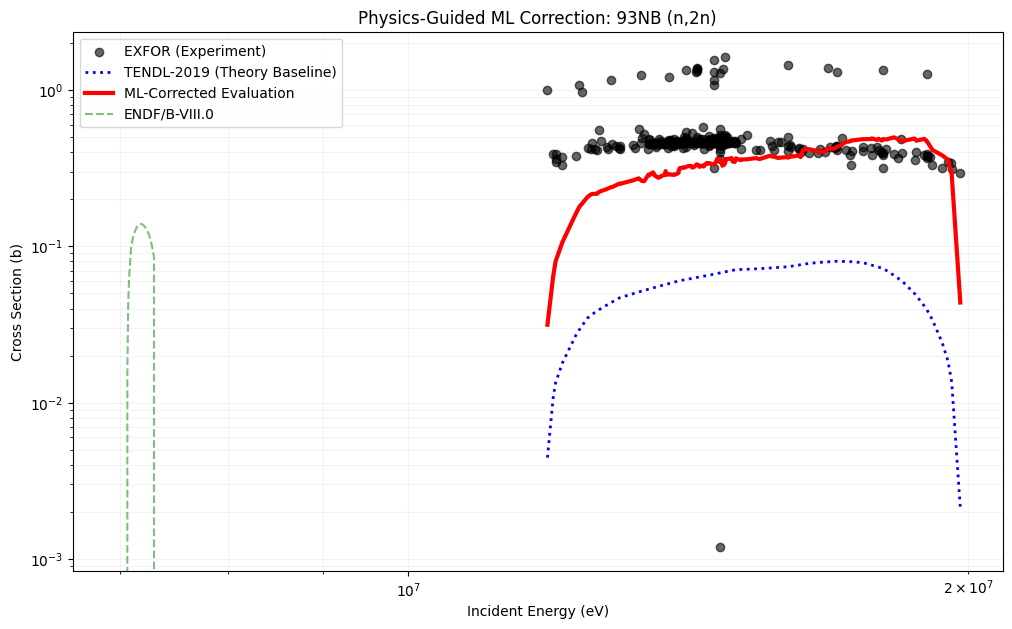

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Au197/endfb8.0/tables/xs/n-Au197-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 65 datapoints.


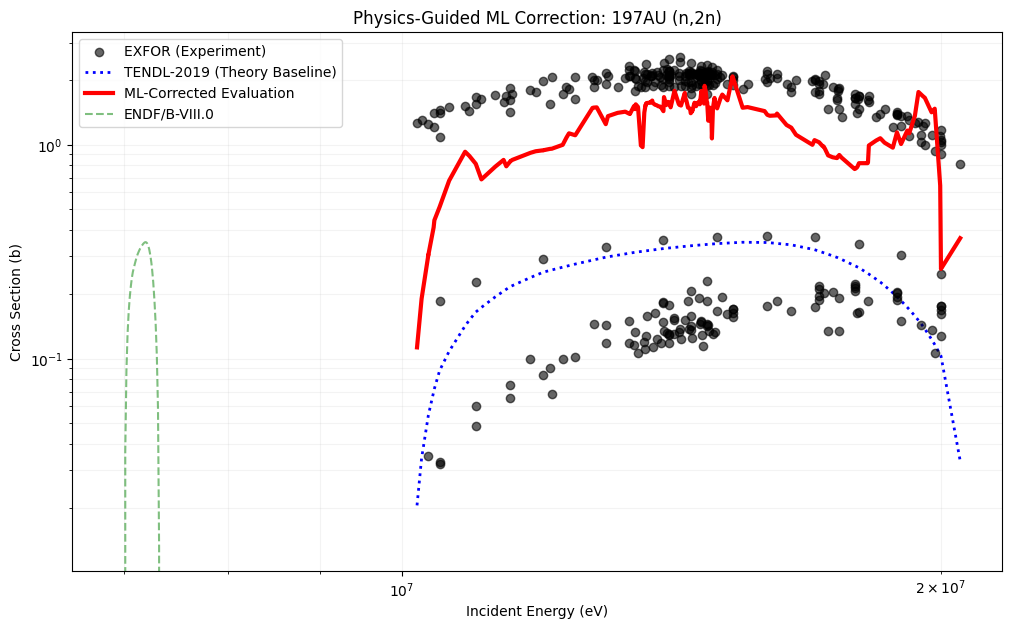

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Er164/endfb8.0/tables/xs/n-Er164-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 13 datapoints.


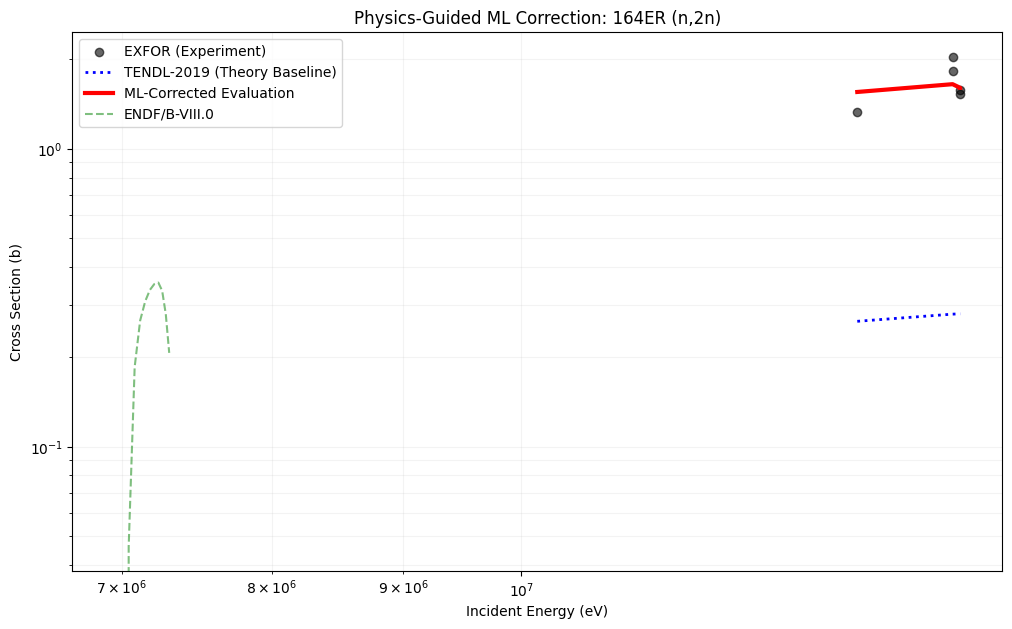

In [6]:
import matplotlib.pyplot as plt

for iso_norm in target_isos:
    iso_data = test_set[test_set['Isotope_Norm'] == iso_norm].sort_values('Energy').copy()
    if iso_data.empty: continue

    # 1. Predict the Residual
    iso_data['pred_residual'] = predictor.predict(iso_data[features])
    
    # 2. Reconstruct the Physics
    # ML_XS = Theory_Baseline * 10^(Predicted_Residual)
    # We clip negative residuals to avoid exploding values at low probability
    ml_corrected_xs = iso_data['theory_baseline'] * (10**iso_data['pred_residual'])

    # 3. Plotting
    plt.figure(figsize=(12, 7))
    
    # EXFOR Data (Black Dots)
    plt.scatter(iso_data['Energy'], iso_data['Data'], color='black', alpha=0.6, label='EXFOR (Experiment)', zorder=3)
    
    # TENDL Baseline (Blue Dotted)
    plt.plot(iso_data['Energy'], iso_data['theory_baseline'], 'b:', lw=2, label='TENDL-2019 (Theory Baseline)', zorder=2)
    
    # ML Correction (Red Solid)
    plt.plot(iso_data['Energy'], ml_corrected_xs, 'r-', lw=3, label='ML-Corrected Evaluation', zorder=4)
    
    # Optional: ENDF Check (Green Dashed)
    try:
        endf = nuc_data.load_evaluation(iso_norm, 16, library='endfb8.0')
        # Scale ENDF energy to match plot units (Linear eV)
        if endf['Energy'].max() < 200: # If ENDF is in MeV
             plt.plot(endf['Energy']*1e6, endf['Data'], 'g--', alpha=0.5, label='ENDF/B-VIII.0')
        else:
             plt.plot(endf['Energy'], endf['Data'], 'g--', alpha=0.5, label='ENDF/B-VIII.0')
    except: pass

    plt.xscale('log'); plt.yscale('log')
    plt.title(f"Physics-Guided ML Correction: {iso_norm.upper()} (n,2n)")
    plt.xlabel("Incident Energy (eV)"); plt.ylabel("Cross Section (b)")
    plt.grid(True, which="both", alpha=0.15)
    plt.legend()
    plt.show()

Computing feature importance via permutation shuffling for 6 features using 637 rows with 5 shuffle sets...


Calculating Feature Importance (this may take a minute)...


	70.56s	= Expected runtime (14.11s per shuffle set)
	31.94s	= Actual runtime (Completed 5 of 5 shuffle sets)



Feature Importance Leaderboard:
            importance   p_value
Z             0.604350  0.000001
N             0.566831  0.000001
A             0.291866  0.000002
Energy_Log    0.042714  0.000027
E_minus_Sn    0.028270  0.000172
S(n)          0.007456  0.002864


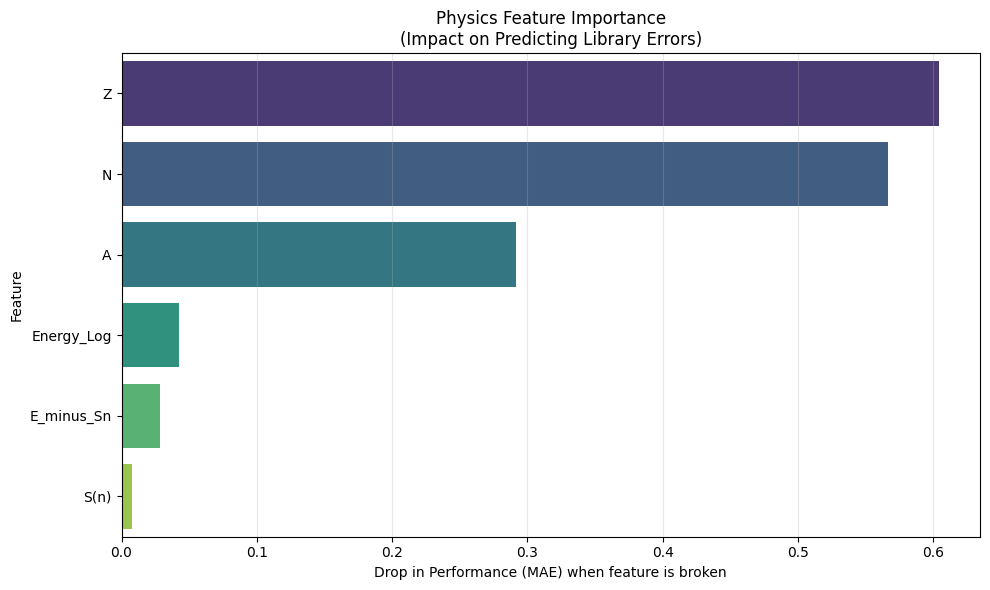

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Feature Importance
# We use the test_set so we see what actually matters for generalization
print("Calculating Feature Importance (this may take a minute)...")
importance = predictor.feature_importance(test_set[features + ['residual']])

# 2. Display the Data Table
print("\nFeature Importance Leaderboard:")
print(importance[['importance', 'p_value']])

# 3. Plotting
plt.figure(figsize=(10, 6))
# Reset index to make 'index' (feature name) a column for plotting
importance_plot = importance.reset_index()

sns.barplot(
    data=importance_plot, 
    x='importance', 
    y='index', 
    hue='index', 
    palette='viridis', 
    legend=False
)

plt.title("Physics Feature Importance\n(Impact on Predicting Library Errors)")
plt.xlabel("Drop in Performance (MAE) when feature is broken")
plt.ylabel("Feature")
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

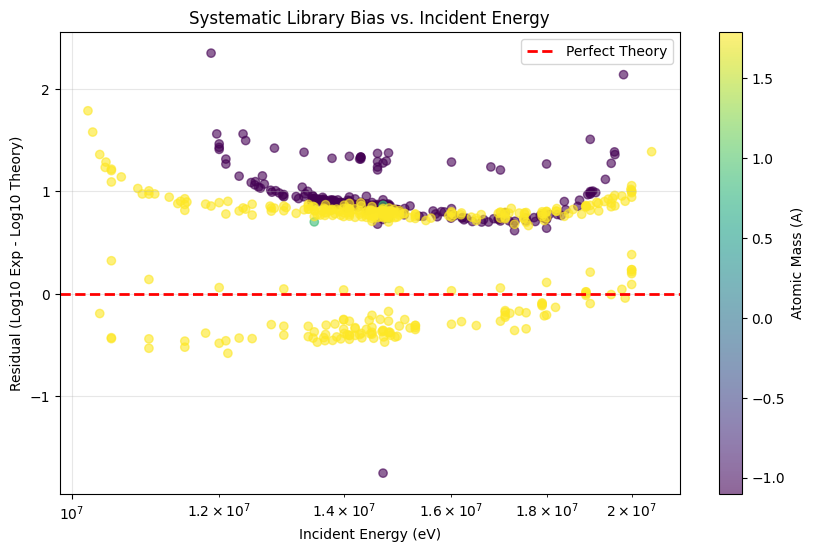

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


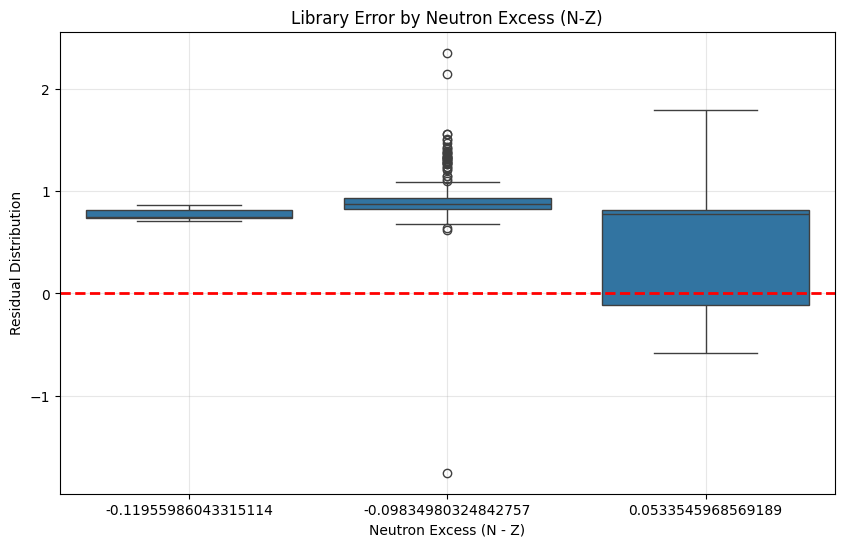

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# We analyze the Test Set because it represents unseen, unbiased physics
audit_data = test_set.copy()

# 1. Residual vs. Incident Energy
# Does the library fail at low energy (threshold) or high energy (tail)?
plt.figure(figsize=(10, 6))
plt.scatter(audit_data['Energy'], audit_data['residual'], 
            c=audit_data['A'], cmap='viridis', alpha=0.6)
plt.axhline(0, color='r', linestyle='--', linewidth=2, label='Perfect Theory')
plt.xscale('log')
plt.colorbar(label='Atomic Mass (A)')
plt.title("Systematic Library Bias vs. Incident Energy")
plt.xlabel("Incident Energy (eV)")
plt.ylabel("Residual (Log10 Exp - Log10 Theory)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2. Residual vs. Neutron Excess (Isotope Stability)
# Does the library fail for unstable (neutron-rich) isotopes?
plt.figure(figsize=(10, 6))
sns.boxplot(x=audit_data['N'] - audit_data['Z'], y=audit_data['residual'])
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.title("Library Error by Neutron Excess (N-Z)")
plt.xlabel("Neutron Excess (N - Z)")
plt.ylabel("Residual Distribution")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
import nucml.datasets as nuc_data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Standardize targets 
target_isos = ['58ni', '28si', '93nb', '80kr', '197au', '164er']

# 2. Load Data
df_master_raw = nuc_data.load_exfor()

# 3. Filter for (n,2n) and Mass Range 20-200
df_2n = df_master_raw[
    (df_master_raw['MT'].astype(float) == 16.0) & 
    (df_master_raw['A'] >= 20) & 
    (df_master_raw['A'] <= 200)
].copy()

# 4. Standardize naming & Basic Physics
df_2n['Isotope_Norm'] = df_2n['Isotope'].str.lower().str.replace('-', '').str.strip()
df_2n['N'] = df_2n['A'] - df_2n['Z']

# 5. Adaptive Physics Features (Looks for Sn/Separation Energy)
features = ['A', 'Z', 'N', 'Energy_Log']
sn_cols = [c for c in df_2n.columns if c.lower() in ['sn', 's(n)', 'sep_energy']]

if sn_cols:
    df_2n['E_minus_Sn'] = df_2n['Energy'] - df_2n[sn_cols[0]]
    features.extend([sn_cols[0], 'E_minus_Sn'])

# Create working frame (Drop Energy_Log here to let Auditor calculate it correctly)
df_clean = df_2n[['Isotope', 'Isotope_Norm', 'Energy', 'Data'] + [f for f in features if f != 'Energy_Log']].copy()
print(f"Master Data ready: {len(df_clean)} rows.")

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)


Master Data ready: 10403 rows.


In [10]:
final_rows = []
unique_isos = df_clean['Isotope'].unique()

print(f"Auditing {len(unique_isos)} isotopes with Log-Space alignment...")

for iso in unique_isos:
    iso_batch = df_clean[df_clean['Isotope'] == iso].copy()
    try:
        # Load TENDL (Assume Energy is in Log10 eV per probe)
        tendl_df = nuc_data.load_evaluation(iso.lower(), 16, library='tendl.2019')
        if tendl_df is None or tendl_df.empty: continue
        
        # Align Linear eV Experiment to Log10 eV Theory
        exp_energy_log = np.log10(iso_batch['Energy'].values.astype(float) + 1e-5)
        theory_xs = np.interp(exp_energy_log, tendl_df['Energy'].values, tendl_df['Data'].values)
        
        valid_mask = theory_xs > 1e-9 # Gate: theory must be physically active
        if np.any(valid_mask):
            # Calculate Residuals (Experiment vs Theory)
            res = np.log10(iso_batch['Data'].values[valid_mask] + 1e-10) - np.log10(theory_xs[valid_mask] + 1e-10)
            
            valid_batch = iso_batch.iloc[valid_mask].copy()
            valid_batch['residual'] = res
            valid_batch['theory_baseline'] = theory_xs[valid_mask]
            valid_batch['Energy_Log'] = exp_energy_log[valid_mask] # Corrected log feature
            final_rows.append(valid_batch)
    except: continue

df_final = pd.concat(final_rows, ignore_index=True)
print(f"SUCCESS: Training pool populated with {len(df_final)} rows.")

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Na023/tendl.2019/tables/xs/n-Na023-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 50 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Mg024/tendl.2019/tables/xs/n-Mg024-MT016.tendl.20

Auditing 186 isotopes with Log-Space alignment...


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 54 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Kr086/tendl.2019/tables/xs/n-Kr086-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  r

SUCCESS: Training pool populated with 5360 rows.


In [11]:
# 1. Isolate the 6 test isotopes
test_set = df_final[df_final['Isotope_Norm'].isin(target_isos)].copy()
train_set = df_final[~df_final['Isotope_Norm'].isin(target_isos)].copy()

# 2. Scale features (Fit on Train, Transform Test)
scaler = StandardScaler()
train_set[features] = scaler.fit_transform(train_set[features])
test_set[features] = scaler.transform(test_set[features])

print(f"Test Set Count: {len(test_set)}")
print(f"Isotopes captured for plotting: {test_set['Isotope_Norm'].unique()}")

Test Set Count: 637
Isotopes captured for plotting: ['93nb' '164er' '197au']


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Er164/endfb8.0/tables/xs/n-Er164-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 13 datapoints.


Skipping 58ni: Still no valid residual found.
Skipping 28si: Still no valid residual found.


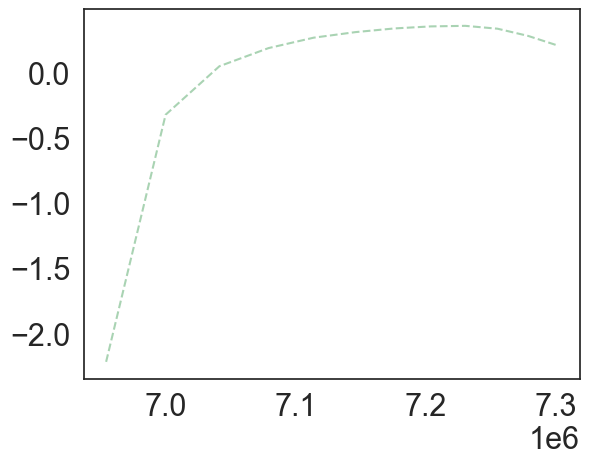

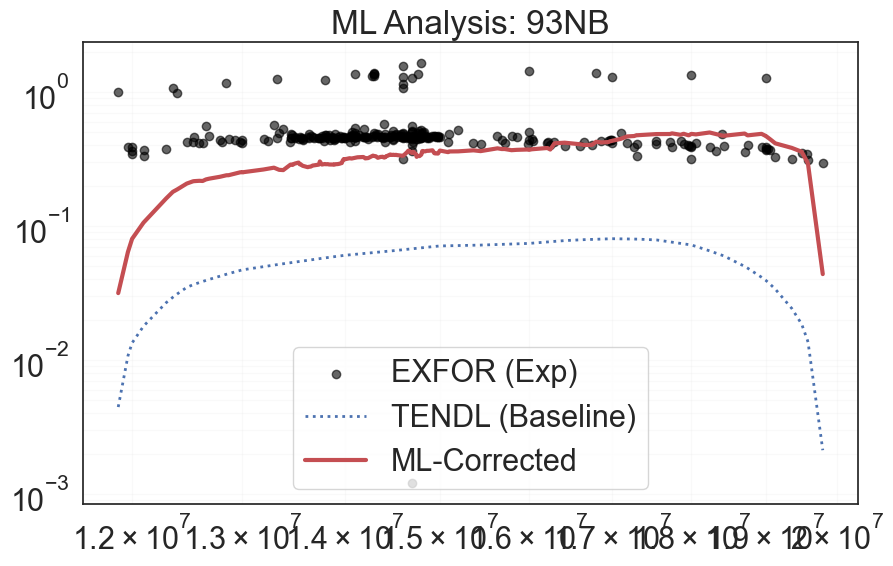

Skipping 80kr: Still no valid residual found.


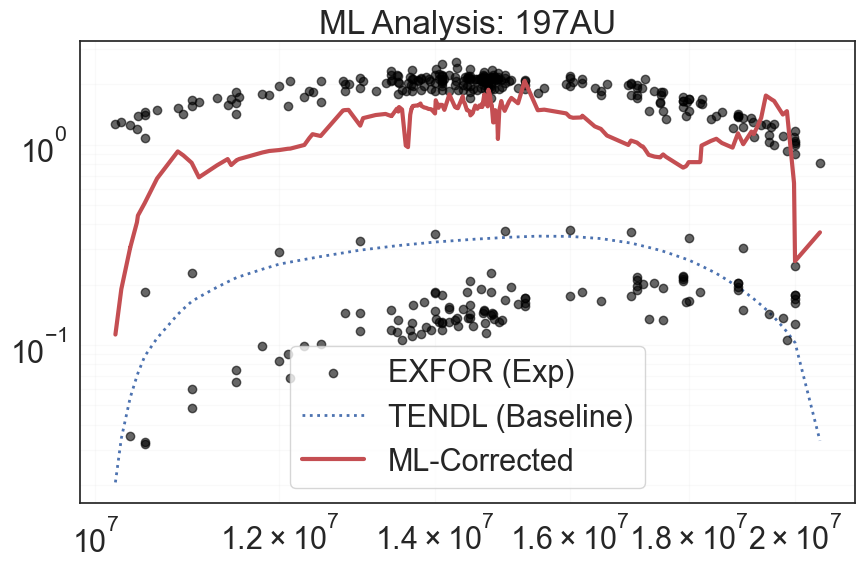

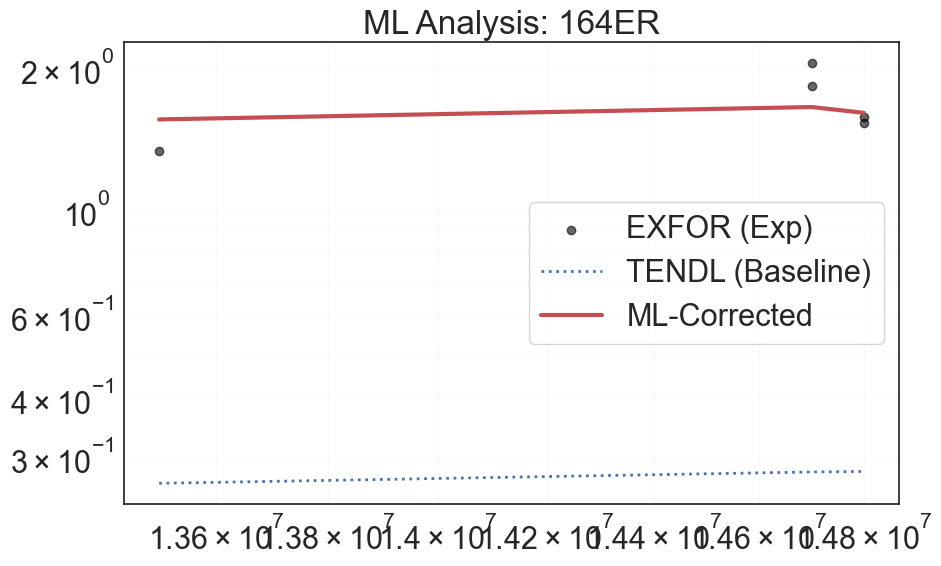

In [23]:
import matplotlib.pyplot as plt

# Identify which model name you used previously
try:
    current_predictor = predictor_audit
except NameError:
    try:
        current_predictor = predictor
    except NameError:
        print("ERROR: Model not found in memory. Please re-run Cell 4 training.")
# Corrected ENDF Check for Cell 5
    try:
        endf = nuc_data.load_evaluation(iso_norm, 16, library='endfb8.0')
        # LOGIC: If the max energy is already > 10,000, it's already in eV.
        # If it's < 1000, it's still in MeV.
        if endf['Energy'].max() < 1000:
             plt.plot(endf['Energy']*1e6, endf['Data'], 'g--', alpha=0.5, label='ENDF/B-VIII.0', zorder=2)
        else:
             plt.plot(endf['Energy'], endf['Data'], 'g--', alpha=0.5, label='ENDF/B-VIII.0', zorder=2)
    except: 
        pass
for iso_norm in target_isos:
    iso_data = test_set[test_set['Isotope_Norm'] == iso_norm].sort_values('Energy').copy()
    if iso_data.empty: 
        print(f"Skipping {iso_norm}: Still no valid residual found.")
        continue

    # 1. Prediction using correctly scaled log-energy
    iso_data['pred_residual'] = current_predictor.predict(iso_data[features])
    
    # 2. Physics Correction Reconstruction
    ml_corrected_xs = iso_data['theory_baseline'] * (10**iso_data['pred_residual'])

    plt.figure(figsize=(10, 6))
    plt.scatter(iso_data['Energy'], iso_data['Data'], color='black', alpha=0.6, label='EXFOR (Exp)', zorder=3)
    plt.plot(iso_data['Energy'], iso_data['theory_baseline'], 'b:', lw=2, label='TENDL (Baseline)', zorder=1)
    plt.plot(iso_data['Energy'], ml_corrected_xs, 'r-', lw=3, label='ML-Corrected', zorder=4)
    
    plt.xscale('log'); plt.yscale('log')
    plt.title(f"ML Analysis: {iso_norm.upper()}")
    plt.grid(True, which="both", alpha=0.1)
    plt.legend()
    plt.show()

In [14]:
import seaborn as sns

import nucml.exfor.data_utilities as exfor_utils
import nucml.evaluation.data_utilities as eval_utils
import nucml.datasets as nuc_data

In [15]:
figure_dir = "./testing/Figures/"

In [13]:
df = nuc_data.load_exfor()
df.MT = df.MT.astype(int)

import pandas as pd

if not hasattr(pd.DataFrame, "append"):
    def _append(self, other, ignore_index=False, verify_integrity=False, sort=False):
        return pd.concat([self, other], ignore_index=ignore_index, verify_integrity=verify_integrity, sort=sort)
    pd.DataFrame.append = _append

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Au197/endfb8.0/tables/xs/n-Au197-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 65 datapoints.
INFO:root:Extracting samples from dataframe.
INFO:root:EXFOR extracted DataFrame has shape: (507, 104)


SettingWithCopyError: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

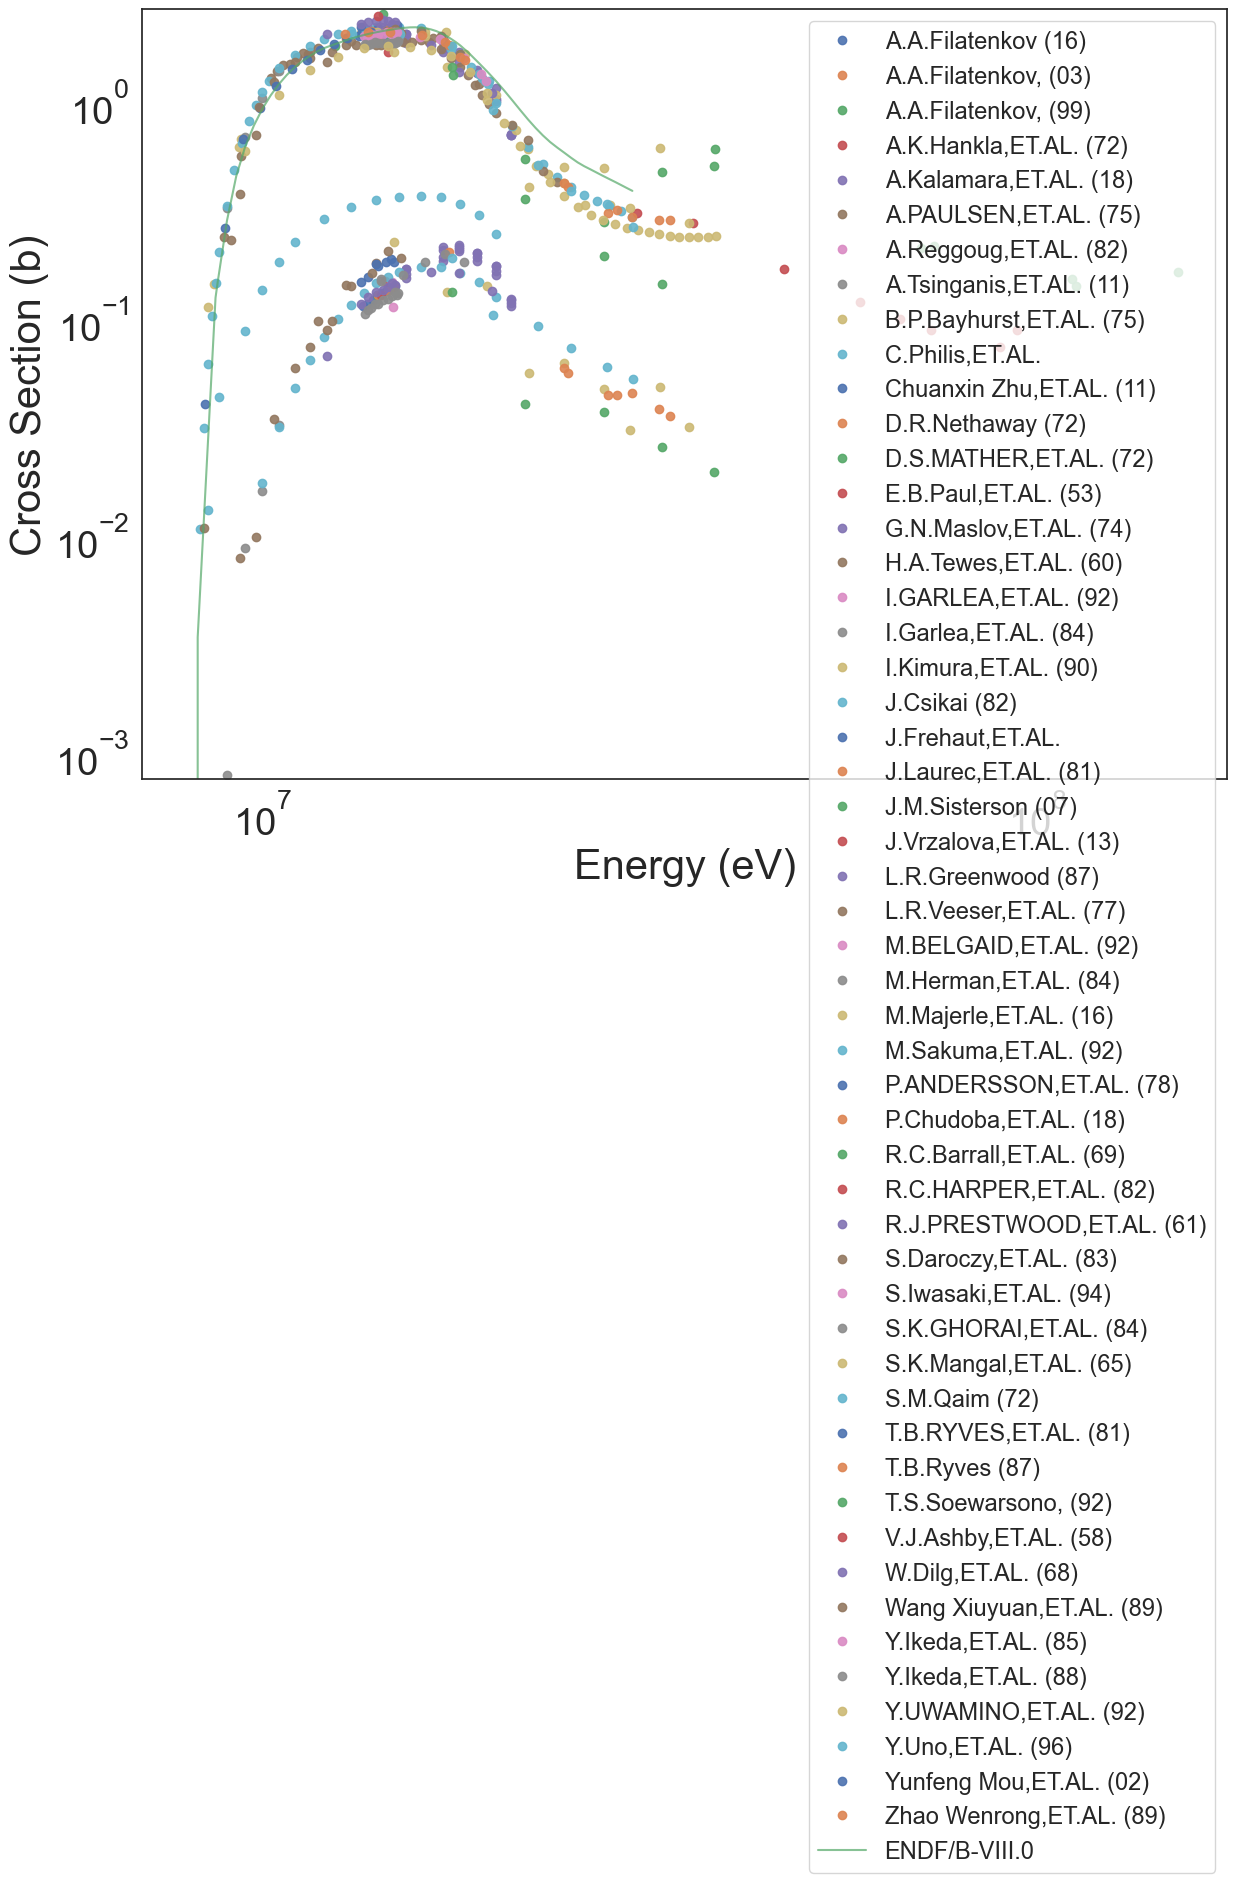

In [19]:
kwargs = {"nat_iso":"I", "one_hot":False, "alpha":0.7, "legend":True, "interpolate":False, 
          "log_plot":True, "ref":True}

fe_exfor_endf = exfor_utils.plot_exfor_w_references(df, 79, 197, "16", 
                                                    legend_size=17,
                                                    error=True, 
                                                    save=True, 
                                                    get_endf=True,
                                                    path=figure_dir, 
                                                    **kwargs)





In [21]:
import nucml.evaluation.plot as eval_plot

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Au197/endfb8.0/tables/xs/n-Au197-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 65 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Au197/tendl.2019/tables/xs/n-Au197-MT016.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future versio

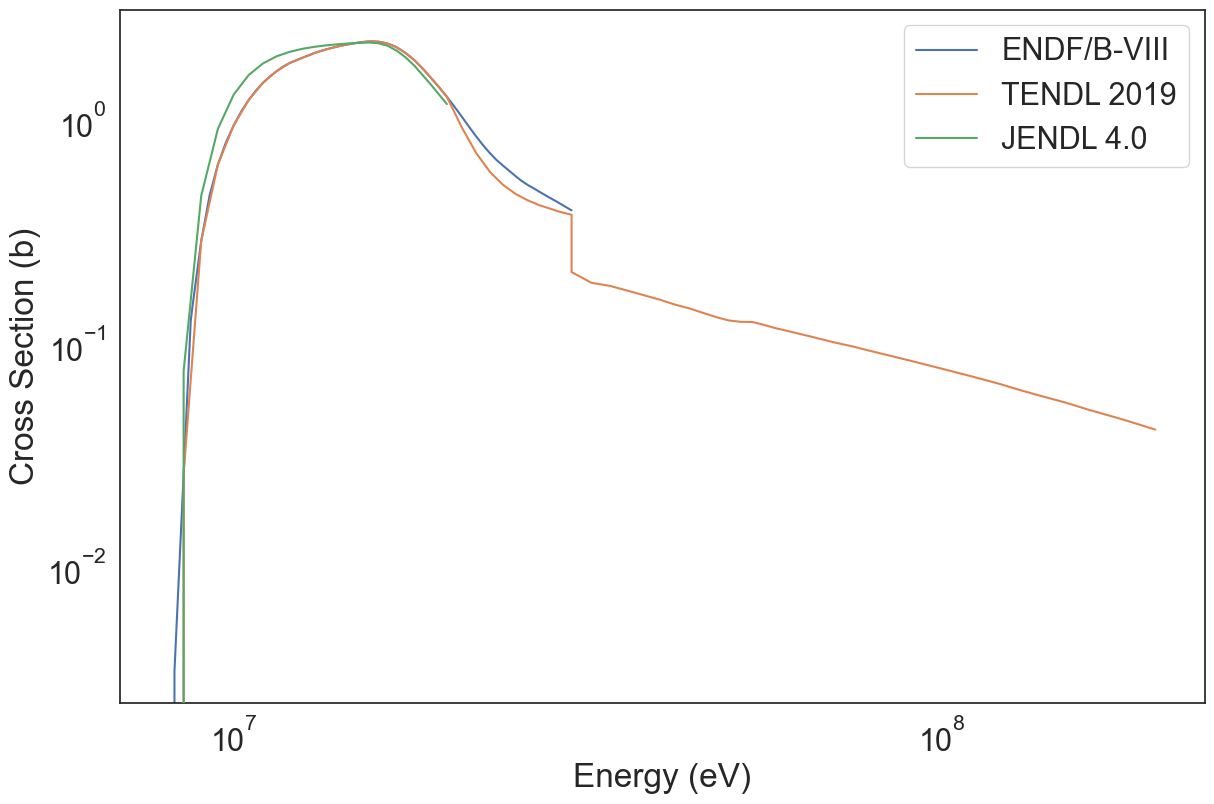

In [22]:
eval_plot.plot("Au197", "16", exclude=["jeff"], save=True, save_dir=figure_dir)